# Chapter 12 - Dynamic Aperture

Dynamic aperture (DA) is a measure of the stable phase space in an accelerator over a specified number of turns. Particles outside of the DA will be driven to large amplitudes where they will be lost. In the following sections, strategies for increasing a ring's DA will be shown in a sample ring.

![Dynamic aperture ray construction](assets/chapter12_dynamic_aperture_rays.svg)

**Figure 1:** The calculation of a dynamic aperture curve in the $x-y$ plane at a given initial $p_z$ value involves calculating aperture curve points (blue dots) along a set of "rays" (dashed lines). The line segments between points is simply for visualization purposes and does not appear in graphs of real data.


In [1]:
# SciBmad builds and tracks the lattice; CairoMakie makes the figures.
using SciBmad
using GTPSA
using CairoMakie

# LinearAlgebra is used for response-matrix solves.
using LinearAlgebra
using Printf

mkpath("assets")


"assets"

## 12.1 Calculating Dynamic Aperture

Points along rays are tested to determine the dynamic-aperture perimeter. All rays begin at the reference orbit. Along each ray, particles with different starting $(x,y)$ positions are tracked to find the boundary between stable and unstable motion.

For this compact SciBmad example, a particle is classified as stable when:

- every tracked coordinate remains finite;
- the transverse coordinates remain inside a generous $50\ \mathrm{mm}$ numerical guard aperture; and
- the particle completes the requested number of turns.

The guard aperture is not the dynamic aperture itself. It prevents a clearly diverging trajectory from consuming unnecessary tracking time.


In [2]:
function build_chapter12_ring(;
    n_cells=16,
    chromatic_strength=300.0,
    harmonic_strength=0.0,
    chromatic_sf_strength=chromatic_strength,
    chromatic_sd_strength=-chromatic_strength,
    harmonic_sf_strength=harmonic_strength,
    harmonic_sd_strength=-harmonic_strength,
)
    elements = SciBmad.LineElement[]

    for i in 1:n_cells
        # Odd cells model the chromatic sextupole families. Even cells model
        # the harmonic families that are turned on in Section 12.2.
        sf = isodd(i) ? chromatic_sf_strength : harmonic_sf_strength
        sd = isodd(i) ? chromatic_sd_strength : harmonic_sd_strength

        # Each compact cell is FODO-like: focus, sextupole, bend, sextupole,
        # defocus. This is a small teaching ring, not the full ESR lattice.
        append!(elements, [
            Quadrupole(name="QF_$i", L=0.25, Kn1=0.8),
            Drift(name="D1A_$i", L=0.20),
            Sextupole(name="SF_$i", L=0.10, Kn2=sf),
            Drift(name="D1B_$i", L=0.20),
            SBend(name="B_$i", L=1.0, angle=2pi / n_cells),
            Drift(name="D2A_$i", L=0.20),
            Sextupole(name="SD_$i", L=0.10, Kn2=sd),
            Drift(name="D2B_$i", L=0.20),
            Quadrupole(name="QD_$i", L=0.25, Kn1=-0.8),
            Drift(name="D3_$i", L=0.40),
        ])
    end

    return Beamline(elements; species_ref=Species("electron"), E_ref=3e9)
end

# The first ring has only the chromatic families. The second includes the
# harmonic families used for the first dynamic-aperture plot.
ring_chromatic = build_chapter12_ring()
ring_with_harmonic_sextupoles = build_chapter12_ring(
    chromatic_strength=300.0,
    harmonic_strength=300.0,
)

@printf("Tracked elements: %d
", length(ring_chromatic.line))
@printf("Circumference: %.3f m
", sum(element.L for element in ring_chromatic.line))


Tracked elements: 160
Circumference: 46.400 m


The aperture point on one ray is found in two stages:

1. scan outward in fixed radial steps until the first unstable launch point is found;
2. refine the last stable/first unstable bracket by bisection.

This is a finite-turn numerical definition of DA. Increasing the tracking time can reveal slow losses and therefore reduce the measured aperture.


In [3]:
function reference_bunch(ring, coordinates)
    coordinates = reshape(coordinates, 1, 6)

    # Recent BeamTracking versions use p_over_q_ref; older versions used R_ref.
    # Keeping both paths lets the notebook run across nearby SciBmad releases.
    if hasproperty(ring, :p_over_q_ref)
        return Bunch(
            coordinates;
            species=ring.species_ref,
            p_over_q_ref=ring.p_over_q_ref,
        )
    elseif hasproperty(ring, :R_ref)
        return Bunch(
            coordinates;
            species=ring.species_ref,
            R_ref=ring.R_ref,
        )
    else
        return Bunch(coordinates; species=ring.species_ref)
    end
end

function stable_motion(
    ring,
    x,
    y;
    pz=0.0,
    n_turns=80,
    guard_aperture=0.05,
)
    # Launch one particle at the requested transverse coordinate and momentum offset.
    bunch = reference_bunch(ring, [x, 0.0, y, 0.0, 0.0, pz])

    try
        for _ in 1:n_turns
            track!(bunch, ring)
            coordinates = Array(bunch.coords.v)

            # Treat NaNs/Infs or very large transverse excursions as particle loss.
            all(isfinite, coordinates) || return false
            maximum(abs, coordinates[:, [1, 3]]) < guard_aperture || return false
        end
    catch
        # Failed tracking usually means the launch point has become unstable.
        return false
    end

    return true
end

function ray_boundary(
    ring,
    theta;
    pz=0.0,
    n_turns=80,
    r_max=0.03,
    radial_step=0.001,
    refinements=6,
)
    last_stable_radius = 0.0

    # First scan outward along one ray until the first unstable point is found.
    for radius in radial_step:radial_step:r_max
        x = radius * cos(theta)
        y = radius * sin(theta)

        if !stable_motion(ring, x, y; pz=pz, n_turns=n_turns)
            low = last_stable_radius
            high = radius

            # Refine the stable/unstable bracket by bisection.
            for _ in 1:refinements
                middle = (low + high) / 2
                middle_is_stable = stable_motion(
                    ring,
                    middle * cos(theta),
                    middle * sin(theta);
                    pz=pz,
                    n_turns=n_turns,
                )
                middle_is_stable ? (low = middle) : (high = middle)
            end

            return low
        end

        last_stable_radius = radius
    end

    # If the whole ray is stable up to r_max, report the scan limit.
    return r_max
end

function dynamic_aperture(
    ring;
    pz_values=[0.0],
    n_angles=9,
    n_turns=80,
    r_max=0.03,
)
    angles = range(0, pi; length=n_angles)
    curves = NamedTuple[]

    # Repeat the ray search for each momentum offset.
    for pz in pz_values
        radii = [
            ray_boundary(
                ring,
                theta;
                pz=pz,
                n_turns=n_turns,
                r_max=r_max,
            )
            for theta in angles
        ]

        push!(curves, (
            pz=pz,
            x=radii .* cos.(angles),
            y=radii .* sin.(angles),
            radii=radii,
        ))
    end

    return curves
end


dynamic_aperture (generic function with 1 method)

The original example evaluates several momentum offsets. For this compact teaching ring, we scan $p_z=0$ through $p_z=0.007$, corresponding to $\delta=0.0\%$ through $0.7\%$ in $0.1\%$ steps. The plot is normalized by nominal beam sizes, $\sigma_x=\sigma_y=1\ \mathrm{mm}$, matching the style of the SciBmad dynamic-aperture example. This demonstration tracks 80 turns and uses 31 rays. Increase `n_turns` and `n_angles` for a production study.


In [4]:
# Scan momentum offsets in 0.1% steps.
pz_values = collect(0.000:0.001:0.007)

# Dynamic aperture is evaluated after turning on the harmonic sextupoles.
corrected_da = dynamic_aperture(
    ring_with_harmonic_sextupoles;
    pz_values=pz_values,
    n_angles=31,
    n_turns=80,
    r_max=0.03,
)

# Print a compact numerical summary for each curve.
for curve in corrected_da
    @printf(
        "pz = %.4f: mean boundary radius = %.2f mm
",
        curve.pz,
        1e3 * sum(curve.radii) / length(curve.radii),
    )
end


pz = 0.0000: mean boundary radius = 21.59 mm
pz = 0.0010: mean boundary radius = 21.29 mm
pz = 0.0020: mean boundary radius = 20.81 mm
pz = 0.0030: mean boundary radius = 20.19 mm
pz = 0.0040: mean boundary radius = 19.27 mm
pz = 0.0050: mean boundary radius = 18.21 mm
pz = 0.0060: mean boundary radius = 16.92 mm
pz = 0.0070: mean boundary radius = 13.26 mm


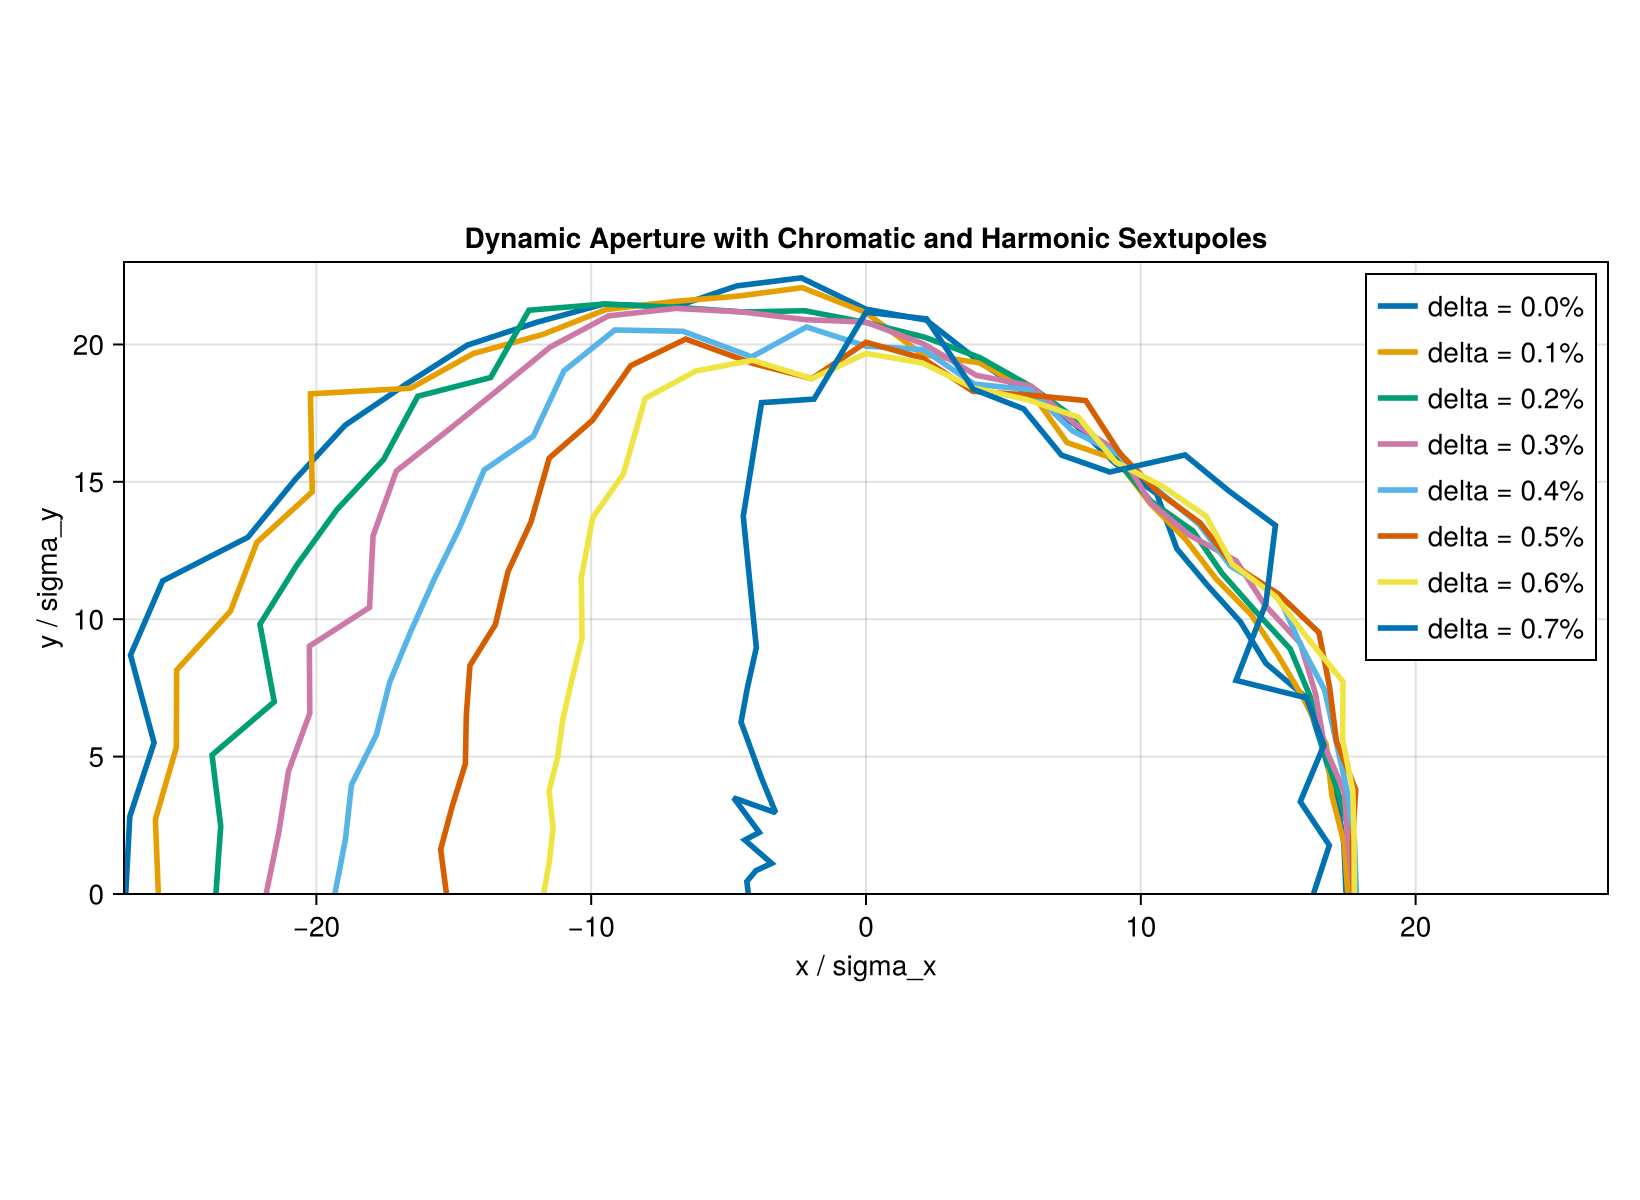

In [5]:
function plot_dynamic_aperture(
    curves;
    title="Dynamic Aperture",
    sigma_x=1.0e-3,
    sigma_y=1.0e-3,
)
    figure = Figure(size=(820, 600))
    axis = Axis(
        figure[1, 1];
        xlabel="x / sigma_x",
        ylabel="y / sigma_y",
        title=title,
        aspect=DataAspect(),
    )

    x_limit = 0.0
    y_limit = 0.0

    for curve in curves
        # Normalize the physical aperture coordinates by nominal beam sizes.
        x_norm = curve.x ./ sigma_x
        y_norm = curve.y ./ sigma_y
        x_limit = max(x_limit, maximum(abs, x_norm))
        y_limit = max(y_limit, maximum(y_norm))
        label = @sprintf("delta = %.1f%%", 100 * curve.pz)
        lines!(axis, x_norm, y_norm; linewidth=2.8, label=label)
    end

    # Use symmetric x limits so x=0 appears at the visual center.
    x_limit = ceil(x_limit)
    y_limit = ceil(y_limit)
    xlims!(axis, -x_limit, x_limit)
    ylims!(axis, 0, y_limit)

    axislegend(axis; position=:rt)
    return figure
end

chromatic_da_figure = plot_dynamic_aperture(
    corrected_da;
    title="Dynamic Aperture with Chromatic and Harmonic Sextupoles",
)
save("assets/chapter12_dynamic_aperture.png", chromatic_da_figure)
chromatic_da_figure


The resulting curves are the SciBmad equivalent of Figure 24 in the original tutorial, plotted in the normalized style used by the SciBmad dynamic-aperture example. Each colored curve represents one momentum offset. The calculated vertices are connected for visualization only, so small jagged features are expected when the scan uses a finite number of rays.

The chromatic-only ring can have a much rougher aperture. Section 12.2 compares it with the corrected ring to show why harmonic sextupoles are useful.


## 12.2 Example: Adding Sextupoles

A common tool for dynamic-aperture optimization is the sextupole. Chromatic sextupoles control the linear chromaticity, while harmonic sextupoles can be placed in low-dispersion regions to reduce nonlinear resonance-driving terms and improve the transverse aperture.

This section adds the harmonic sextupole families and checks whether the on-momentum dynamic aperture improves.


### Step 1: Define the Chromatic Sextupole Families

The chromatic sextupoles are the `SF` and `SD` families in the dispersive arc cells. In the compact SciBmad ring, these are already created by `build_chapter12_ring`: odd-numbered cells contain the chromatic families, with `SF` and `SD` using opposite signs.


### Step 2: Add the Harmonic Sextupole Families

The harmonic sextupoles occupy the alternate cells. Earlier they were present with zero strength; here we turn them on by rebuilding the same linear lattice with a nonzero harmonic sextupole strength.


In [6]:
# Rebuild the same linear lattice, now with nonzero harmonic sextupoles.
ring_with_harmonic_sextupoles = build_chapter12_ring(
    chromatic_strength=300.0,
    harmonic_strength=300.0,
)

@printf("Chromatic SF/SD strength magnitude: %.1f\n", 300.0)
@printf("Harmonic  SF/SD strength magnitude: %.1f\n", 300.0)

Chromatic SF/SD strength magnitude: 300.0
Harmonic  SF/SD strength magnitude: 300.0


### Step 3: Make Room for the Sextupoles in the Cell Layout

In a lattice file this usually means splitting drifts and inserting sextupole elements into the FODO cells. In this compact SciBmad example, that layout is already encoded in `build_chapter12_ring`, where each cell contains drifts around the `SF` and `SD` sextupole locations.


### Step 4: Recalculate the On-Momentum Dynamic Aperture

To check whether the harmonic family helps, repeat the ray search at `p_z = 0` before and after the harmonic sextupoles are turned on.


In [7]:
# Compare on-momentum dynamic aperture before and after the harmonic family is added.
chromatic_only_da = dynamic_aperture(
    ring_chromatic;
    pz_values=[0.0],
    n_angles=31,
    n_turns=80,
    r_max=0.03,
)

harmonic_da = dynamic_aperture(
    ring_with_harmonic_sextupoles;
    pz_values=[0.0],
    n_angles=31,
    n_turns=80,
    r_max=0.03,
)

before_mean = 1e3 * sum(chromatic_only_da[1].radii) / length(chromatic_only_da[1].radii)
after_mean = 1e3 * sum(harmonic_da[1].radii) / length(harmonic_da[1].radii)

@printf("Mean on-momentum boundary before harmonic sextupoles: %.2f mm\n", before_mean)
@printf("Mean on-momentum boundary after harmonic sextupoles:  %.2f mm\n", after_mean)

Mean on-momentum boundary before harmonic sextupoles: 10.72 mm
Mean on-momentum boundary after harmonic sextupoles:  21.59 mm


### Step 5: Plot the Before-and-After Aperture Boundaries

The two curves show the chromatic-only ring and the ring with the harmonic sextupole families enabled. The coordinates are normalized by nominal beam sizes, matching the earlier dynamic-aperture plots.


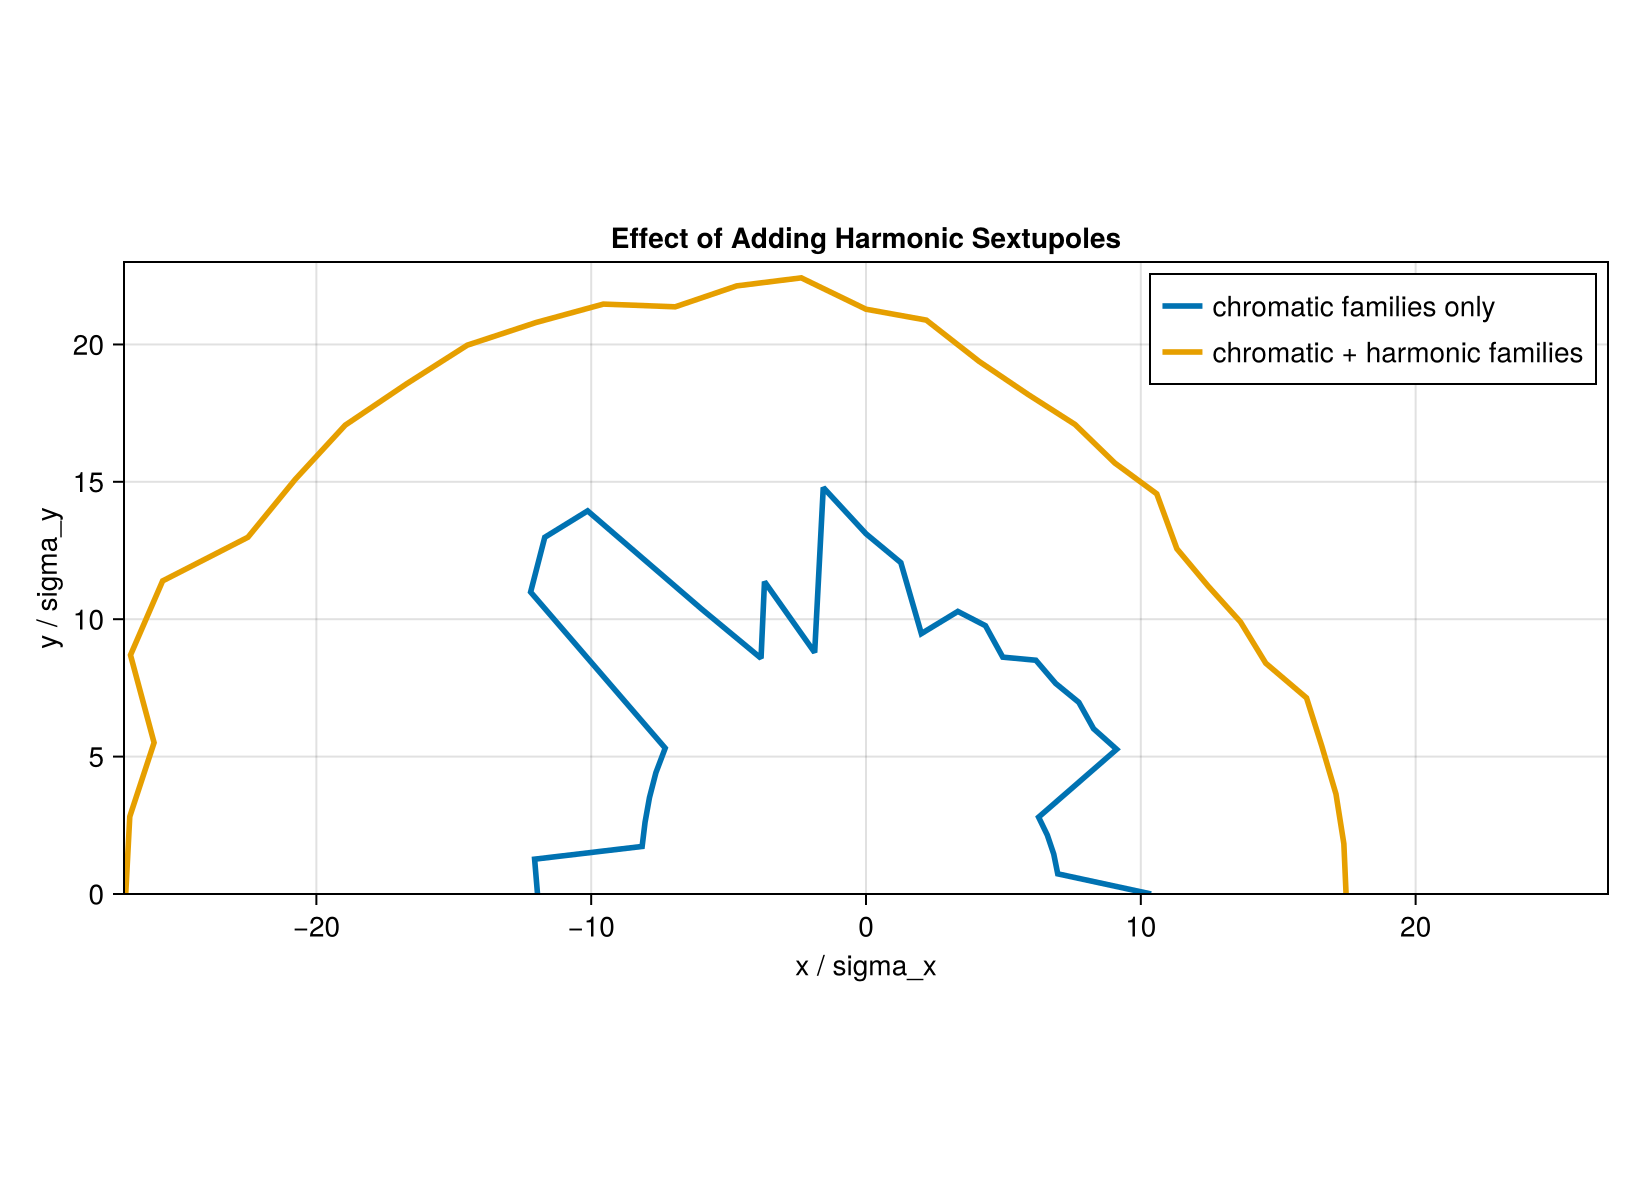

In [8]:
comparison_figure = Figure(size=(820, 600))
comparison_axis = Axis(
    comparison_figure[1, 1];
    xlabel="x / sigma_x",
    ylabel="y / sigma_y",
    title="Effect of Adding Harmonic Sextupoles",
    aspect=DataAspect(),
)

sigma_x = 1.0e-3
sigma_y = 1.0e-3

lines!(
    comparison_axis,
    chromatic_only_da[1].x ./ sigma_x,
    chromatic_only_da[1].y ./ sigma_y;
    linewidth=2.8,
    label="chromatic families only",
)

lines!(
    comparison_axis,
    harmonic_da[1].x ./ sigma_x,
    harmonic_da[1].y ./ sigma_y;
    linewidth=2.8,
    label="chromatic + harmonic families",
)

comparison_x_limit = ceil(max(
    maximum(abs, chromatic_only_da[1].x ./ sigma_x),
    maximum(abs, harmonic_da[1].x ./ sigma_x),
))
comparison_y_limit = ceil(max(
    maximum(chromatic_only_da[1].y ./ sigma_y),
    maximum(harmonic_da[1].y ./ sigma_y),
))
xlims!(comparison_axis, -comparison_x_limit, comparison_x_limit)
ylims!(comparison_axis, 0, comparison_y_limit)

axislegend(comparison_axis; position=:rt)
save("assets/chapter12_adding_sextupoles.png", comparison_figure)
comparison_figure

### Step 6: Interpret the Result

For this demonstration setting, the harmonic family increases the mean on-momentum boundary radius. This is not a general rule that stronger sextupoles always improve DA. Sextupole strengths and phase relationships must be optimized, and the final settings must be checked over the required momentum range and tracking time.


## 12.3 Example: Chromaticity Correction

After adding sextupole families, the first correction is the linear chromaticity. We use two knobs, `OSF` and `OSD`, to control all focusing and defocusing chromatic sextupoles as two families. The target chromaticities are `chrom.a = 1` and `chrom.b = 1`.

The response matrix is computed with GTPSA by treating the two sextupole knobs as descriptor parameters, so the matrix is `d(chromaticity) / d(OSF, OSD)` rather than a finite-difference estimate.


### Step 1: Define the OSF and OSD Knobs

The vector `os = [OSF, OSD]` stores the two sextupole-family knobs. In this compact ring, changing those knobs means rebuilding the ring with new common strengths for the chromatic `SF` and `SD` families.


In [9]:
function ring_with_os_knobs(os; harmonic_strength=0.0)
    # os[1] is the OSF knob; os[2] is the OSD knob.
    return build_chapter12_ring(
        chromatic_sf_strength=os[1],
        chromatic_sd_strength=os[2],
        harmonic_strength=harmonic_strength,
    )
end

ring_with_os_knobs (generic function with 1 method)

### Step 2: Make OSF and OSD GTPSA Parameters

The two sextupole knobs become descriptor parameters. After `twiss` is evaluated, the chromaticities carry derivatives with respect to `OSF` and `OSD`, which form the response matrix.


In [10]:
const CH12_CHROM_ZERO_POWER = [0, 0, 0, 0, 0, 0]

ch12_chrom_scalar(x::Real) = Float64(x)
ch12_chrom_scalar(x) = Float64(x[CH12_CHROM_ZERO_POWER])
ch12_chrom_parameter_gradient(x) = GTPSA.gradient(x, include_params=true)[7:end]

function ch12_chromaticity_terms(tw)
    # chromaticity is d(tune)/dp_z. The [:] keeps OSF/OSD parameter dependence.
    return Any[
        par(tw.tunes[1], 6)[[CH12_CHROM_ZERO_POWER...,:]],
        par(tw.tunes[2], 6)[[CH12_CHROM_ZERO_POWER...,:]],
    ]
end

function chromaticity_and_response(os; harmonic_strength=0.0)
    # The two descriptor parameters are the OSF and OSD knobs.
    descriptor = Descriptor([1, 1, 1, 1, 1, 1], 3, ones(Int, 2), 1)
    p = params(descriptor)
    ring = ring_with_os_knobs(os .+ p; harmonic_strength=harmonic_strength)
    tw = twiss(ring; GTPSA_descriptor=descriptor)
    chromaticity_terms = ch12_chromaticity_terms(tw)

    chromaticity = Float64[ch12_chrom_scalar(term) for term in chromaticity_terms]
    response = reduce(
        vcat,
        (ch12_chrom_parameter_gradient(term)' for term in chromaticity_terms),
    )

    return chromaticity, Matrix{Float64}(response)
end

chromaticity_from_gtpsa(os; harmonic_strength=0.0) =
    chromaticity_and_response(os; harmonic_strength=harmonic_strength)[1]

chromaticity_response(os; harmonic_strength=0.0) =
    chromaticity_and_response(os; harmonic_strength=harmonic_strength)[2]

chromaticity_response (generic function with 1 method)

### Step 3: Define the Chromaticity Targets

Set the desired chromaticities to small positive values. Here both transverse planes target chromaticity 1.


In [11]:
target_chromaticity = [1.0, 1.0]
initial_os = [2.0, -2.0]

2-element Vector{Float64}:
  2.0
 -2.0

### Step 4: Build the Response-Matrix Correction Loop

Each iteration computes the current chromaticity and GTPSA response matrix, solves for the knob update, and applies the correction.


In [12]:
function correct_chromaticity(os0; target=target_chromaticity, max_iter=5, tolerance=1e-5)
    os = copy(os0)
    history = NamedTuple[]

    for iteration in 1:max_iter
        chromaticity, response = chromaticity_and_response(os)
        residual = target .- chromaticity
        push!(history, (
            iteration=iteration,
            os=copy(os),
            chromaticity=chromaticity,
            response=response,
        ))
        norm(residual) < tolerance && break

        # Linear correction: response * dOS = target - current.
        os .+= response \ residual
    end

    return os, history
end

correct_chromaticity (generic function with 1 method)

### Step 5: Run the Optimizer and Store the Corrected Ring

The optimized knobs are saved in `corrected_os`, and the corrected lattice is stored as `ring_chromaticity_corrected` for later dynamic-aperture checks.


In [13]:
corrected_os, correction_history = correct_chromaticity(initial_os; target=target_chromaticity)
corrected_chromaticity = chromaticity_from_gtpsa(corrected_os)
ring_chromaticity_corrected = ring_with_os_knobs(corrected_os)

println("Chromaticity correction history:")
for step in correction_history
    @printf(
        "  iter %d: OSF = % .6f, OSD = % .6f, chrom = (% .6f, % .6f), cond(R) = %.3e\n",
        step.iteration,
        step.os[1],
        step.os[2],
        step.chromaticity[1],
        step.chromaticity[2],
        cond(step.response),
    )
end

@printf("\nCorrected OSF = %.6f\n", corrected_os[1])
@printf("Corrected OSD = %.6f\n", corrected_os[2])
@printf("Corrected chromaticities = (%.6f, %.6f)\n", corrected_chromaticity[1], corrected_chromaticity[2])

Chromaticity correction history:
  iter 1: OSF =  2.000000, OSD = -2.000000, chrom = (-0.588870, -0.188155), cond(R) = 4.047e+01
  iter 2: OSF =  21.124125, OSD = -20.472464, chrom = ( 1.000000,  1.000000), cond(R) = 4.047e+01

Corrected OSF = 21.124125
Corrected OSD = -20.472464
Corrected chromaticities = (1.000000, 1.000000)


### Step 6: Use the Corrected Ring for Later DA Checks

The corrected ring can be passed to `dynamic_aperture(...)` when comparing aperture before and after chromaticity correction.


## 12.4 Example: W-Function Optimization

The W-function optimization uses the full ESR-style lattice prepared for this chapter. The variables are four paired sextupole-overlay knobs and four IP trombone knobs. The targets are the W-function components in both planes at `ip6` and `marc_end`.


### Step 1: Load the ESR Optimization Ring and Locate the W Targets

Load the chapter-specific ESR lattice file, attach the helper compatibility definitions needed by the generated lattice, and find the two table indices where the W residual will be evaluated.


In [14]:
using SciBmad
using GTPSA
using LinearAlgebra
using Printf

# Compatibility helpers for the generated ESR lattice file.
if !isdefined(Main, :PhaseRef)
    const PhaseRef = PhaseReference
end

if !isdefined(Main, :BeamlineChildRef)
    struct BeamlineChildRef
        beamline_index::Int
    end
end

findchildren(element, ring) = [
    BeamlineChildRef(i) for (i, candidate) in enumerate(ring.line) if candidate === element
]

# The optimizer uses the full ESR-style lattice prepared for the 12.4 example.
# esr-da-opt.jl lives with the chapter 12 lattice files; it includes the base
# ESR ring from lattices/common and attaches the chapter-specific trombone maps.
esr_opt_file_candidates = [
    joinpath(pwd(), "lattices", "chapter_12", "esr-da-opt.jl"),
    joinpath(pwd(), "Ring_Design_Tutorial_SciBmad", "lattices", "chapter_12", "esr-da-opt.jl"),
    joinpath(pwd(), "..", "Ring_Design_Tutorial_SciBmad", "lattices", "chapter_12", "esr-da-opt.jl"),
]
esr_opt_file = normpath(first(filter(isfile, esr_opt_file_candidates)))

if !isdefined(Main, :ring_12_4)
    ring_12_4 = include(esr_opt_file)
end

# The original Bmad file targets IP6 and END_7. This SciBmad lattice uses
# marc_end as the corresponding end-of-arc-7 target marker.
ch12_w_target_markers = [:ip6, :marc_end]
ch12_w_target_indices = [
    findchildren(getfield(Main, marker_name), ring_12_4)[1].beamline_index
    for marker_name in ch12_w_target_markers
]

@printf("Full 12.4 ring elements: %d
", length(ring_12_4.line))
@printf("W targets: %s
", join(string.(ch12_w_target_markers), ", "))


Full 12.4 ring elements: 6890
W targets: ip6, marc_end


### Step 2: Note Where the Phase Trombones Enter

With these overlays, the W function can be optimized; however, without proper phasing between arcs, sextupoles may not be efficient in the correction. In order to fix phases between sextupoles for the optimization, it is often useful to use a phase trombone. Phase trombones are artificial elements that are used to set a phase advance without altering optics. We will need three phase trombones, two surrounding the IP and one to fix the tune. We will fix tune in the 2 o'clock tune cell.

In this SciBmad tutorial, we have defined the trombone map in `lattices/chapter_12/trombone_utils.jl`, and we have added the trombones to the ring in `lattices/chapter_12/esr-da-opt.jl`. The relevant setup in `esr-da-opt.jl` is shown below for reference; *(this is explanatory code, not a cell that needs to be run here.)*

```julia
# Attach phase trombones to marker locations. The map itself is defined in
# trombone_utils.jl so the chapter 12-specific mechanism is easy to inspect.
trombones = [mlrf_6, mlrr_6, ip8, ip10, ip12, ip2, ip4]
tw = twiss(ring)
t = tw.table

attach_trombone!(mlrf_6, ring, t, DefExpr(() -> CONTROLS.dnux_mlrf_6), DefExpr(() -> CONTROLS.dnuy_mlrf_6))
attach_trombone!(mlrr_6, ring, t, DefExpr(() -> CONTROLS.dnux_mlrr_6), DefExpr(() -> CONTROLS.dnuy_mlrr_6))
attach_trombone!(ip8, ring, t, DefExpr(() -> CONTROLS.dnux_ip8), DefExpr(() -> CONTROLS.dnuy_ip8))
attach_trombone!(ip10, ring, t, DefExpr(() -> CONTROLS.dnux_ip10), DefExpr(() -> CONTROLS.dnuy_ip10))
attach_trombone!(ip12, ring, t, DefExpr(() -> CONTROLS.dnux_ip12), DefExpr(() -> CONTROLS.dnuy_ip12))
attach_trombone!(ip2, ring, t, DefExpr(() -> CONTROLS.dnux_ip2), DefExpr(() -> CONTROLS.dnuy_ip2))
attach_trombone!(ip4, ring, t, DNUX_IP4, DNUY_IP4)
```


### Step 3: Convert Twiss Chromatic Derivatives into W Residuals

SciBmad returns Twiss quantities as TPSA objects when a `GTPSA_descriptor` is supplied. The first-order `p_z` coefficient gives the chromatic derivative. For the Jacobian, the coefficient extraction must keep descriptor-parameter dependence so GTPSA can provide derivatives with respect to the optimization knobs.


In [15]:
const CH12_W_ZERO_POWER = [0, 0, 0, 0, 0, 0]
const CH12_W_PZ_POWER = [0, 0, 0, 0, 0, 1]

ch12_scalar_constant(x::Number) = Float64(x)
ch12_scalar_constant(x) = Float64(x[CH12_W_ZERO_POWER])

function ch12_w_ab_plain(beta, alpha)
    beta0 = beta[CH12_W_ZERO_POWER]
    alpha0 = alpha[CH12_W_ZERO_POWER]
    dbeta_dpz = beta[CH12_W_PZ_POWER]
    dalpha_dpz = alpha[CH12_W_PZ_POWER]

    A = dalpha_dpz - alpha0 / beta0 * dbeta_dpz
    B = dbeta_dpz / beta0
    return [A, B]
end

# These versions keep descriptor-parameter dependence after extracting the
# phase-space coefficient, which lets GTPSA provide d(residual)/d(knob).
ch12_constant_keep_params(x) = x[[CH12_W_ZERO_POWER...,:]]
ch12_pz_coefficient_keep_params(x) = par(x, 6)[[CH12_W_ZERO_POWER...,:]]
ch12_parameter_gradient(x) = GTPSA.gradient(x, include_params=true)[7:end]

function ch12_w_ab_keep_params(beta, alpha)
    beta0 = ch12_constant_keep_params(beta)
    alpha0 = ch12_constant_keep_params(alpha)
    dbeta_dpz = ch12_pz_coefficient_keep_params(beta)
    dalpha_dpz = ch12_pz_coefficient_keep_params(alpha)

    A = dalpha_dpz - alpha0 / beta0 * dbeta_dpz
    B = dbeta_dpz / beta0
    return [A, B]
end


ch12_w_ab_keep_params (generic function with 1 method)

### Step 4: Define the Eight Optimization Knobs

The optimizer works with an eight-entry vector. The first four entries move paired sextupole families with opposite signs; the last four entries change the horizontal and vertical phase trombones around IP6. The compensating IP4 trombone in the lattice file keeps the total tune shift balanced.


In [16]:
function ch12_reset_w_controls!()
    for name in fieldnames(typeof(CONTROLS))
        setfield!(CONTROLS, name, 0.0)
    end
end

function ch12_apply_w_knobs!(x)
    ch12_reset_w_controls!()

    # Paired sextupole overlay variables:
    # OF_5, OD_5, OF_7, OD_7 move paired sextupole families as +x and -x.
    CONTROLS.dksf1_5 = x[1]
    CONTROLS.dksf2_5 = -x[1]
    CONTROLS.dksd1_5 = x[2]
    CONTROLS.dksd2_5 = -x[2]
    CONTROLS.dksf1_7 = x[3]
    CONTROLS.dksf2_7 = -x[3]
    CONTROLS.dksd1_7 = x[4]
    CONTROLS.dksd2_7 = -x[4]

    # TROMBONES[x1, x2, y1, y2]. The compensating IP4 trombone defined in
    # lattices/chapter_12/esr-da-opt.jl keeps the total tune shift balanced.
    CONTROLS.dnux_mlrf_6 = x[5]
    CONTROLS.dnux_mlrr_6 = x[6]
    CONTROLS.dnuy_mlrf_6 = x[7]
    CONTROLS.dnuy_mlrr_6 = x[8]
end


ch12_apply_w_knobs! (generic function with 1 method)

### Step 5: Build the Residual and GTPSA Response Matrix

`ch12_w_residual` evaluates the eight W residual components. `ch12_w_residual_and_jacobian` promotes the eight knobs to GTPSA descriptor parameters and extracts the full response matrix directly from the TPSA residual terms.


In [17]:
function ch12_w_residual(x; ring=ring_12_4)
    ch12_apply_w_knobs!(x)
    tw = twiss(ring; GTPSA_descriptor=Descriptor(6, 2))
    residual_terms = Any[]

    for idx in ch12_w_target_indices
        append!(residual_terms, ch12_w_ab_plain(tw.table.beta_1[idx], tw.table.alpha_1[idx]))
        append!(residual_terms, ch12_w_ab_plain(tw.table.beta_2[idx], tw.table.alpha_2[idx]))
    end

    residual = Float64[ch12_scalar_constant(term) for term in residual_terms]
    ch12_reset_w_controls!()
    return residual
end

function ch12_w_report(x; ring=ring_12_4)
    residual = ch12_w_residual(x; ring)
    @printf("total residual norm = %.9g\n", norm(residual))

    for k in eachindex(ch12_w_target_markers)
        offset = 4 * (k - 1) + 1
        wa = hypot(residual[offset], residual[offset + 1])
        wb = hypot(residual[offset + 2], residual[offset + 3])
        @printf("  %-8s  Wa = %10.6g   Wb = %10.6g\n", String(ch12_w_target_markers[k]), wa, wb)
    end

    println("  knobs = ", repr(x))
    return residual
end

function ch12_w_residual_and_jacobian(x; ring=ring_12_4)
    # Find the closed orbit at the ordinary floating-point knob setting first.
    # This avoids mixing ForwardDiff dual numbers from the closed-orbit search
    # with GTPSA descriptor parameters in the custom trombone maps.
    ch12_apply_w_knobs!(x)
    co_info = find_closed_orbit(ring)

    descriptor = Descriptor([1, 1, 1, 1, 1, 1], 3, ones(Int, 8), 1)
    p = params(descriptor)
    ch12_apply_w_knobs!(x .+ p)

    tw = twiss(ring; GTPSA_descriptor=descriptor, co_info=co_info)
    residual_terms = TPS64[]

    for idx in ch12_w_target_indices
        append!(residual_terms, ch12_w_ab_keep_params(tw.table.beta_1[idx], tw.table.alpha_1[idx]))
        append!(residual_terms, ch12_w_ab_keep_params(tw.table.beta_2[idx], tw.table.alpha_2[idx]))
    end

    residual = Float64[term[CH12_W_ZERO_POWER] for term in residual_terms]
    jacobian = reduce(vcat, (ch12_parameter_gradient(term)' for term in residual_terms))
    ch12_reset_w_controls!()
    return residual, Matrix{Float64}(jacobian)
end


ch12_w_residual_and_jacobian (generic function with 1 method)

### Step 6: Define a Damped Least-Squares Optimizer

The correction loop solves a damped least-squares system and tests a small grid of damping and step-scale values. This is the same response-matrix idea as earlier sections, but with an 8-by-8 Jacobian from GTPSA.


In [18]:
function ch12_optimize_w(; maxiter=8)
    x = zeros(8)

    # A small Levenberg-Marquardt grid is enough for this 8-variable match.
    # The grid keeps the step stable when the local linear model is too bold.
    lambdas = [1e1, 1e2, 1e3, 1e4, 1e5]
    scales = [1.0, 0.5, 0.25, 0.1, 0.05]

    for iter in 0:(maxiter - 1)
        residual, jacobian = ch12_w_residual_and_jacobian(x)
        norm_now = norm(residual)
        @printf("iter %2d  residual norm = %.9g  cond(J) = %.3e\n", iter, norm_now, cond(jacobian))
        println("  knobs = ", repr(round.(x; digits=6)))

        best_x = copy(x)
        best_norm = norm_now
        best_description = "none"

        for lambda in lambdas
            step = -(jacobian' * jacobian + lambda * I) \ (jacobian' * residual)
            for scale in scales
                trial_x = x .+ scale .* step
                trial_norm = norm(ch12_w_residual(trial_x))

                if isfinite(trial_norm) && trial_norm < best_norm
                    best_x = trial_x
                    best_norm = trial_norm
                    best_description = @sprintf(
                        "lambda %.1e, scale %.2g, step %.3g",
                        lambda,
                        scale,
                        norm(step),
                    )
                end
            end
        end

        @printf("  accepted residual norm = %.9g via %s\n", best_norm, best_description)
        best_norm >= norm_now - 1e-9 && break
        x = best_x
    end

    println()
    println("Final W report:")
    ch12_w_report(x)
    return x
end


ch12_optimize_w (generic function with 1 method)

### Step 7: Run the Optimizer and Inspect the Optimized Knobs

Print the initial residual, run eight optimizer iterations, and store the accepted knob vector in `optimized_ch12_w_knobs`.


In [19]:
println("Initial W report:")
ch12_w_report(zeros(8))

optimized_ch12_w_knobs = ch12_optimize_w(maxiter=8)


Initial W report:
total residual norm = 427.616822
  ip6       Wa =    233.636   Wb =    109.385
  marc_end  Wa =    268.344   Wb =    210.468
  knobs = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
iter  0  residual norm = 427.616824  cond(J) = 8.449e+01
  knobs = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  accepted residual norm = 264.779892 via lambda 1.0e+03, scale 0.5, step 2.57
iter  1  residual norm = 264.779891  cond(J) = 1.930e+01
  knobs = [-0.880027, -0.098911, -0.606366, -0.069503, 0.217514, 0.091447, -0.664752, 0.022678]
  accepted residual norm = 163.527597 via lambda 1.0e+04, scale 1, step 1.05
iter  2  residual norm = 163.527598  cond(J) = 1.594e+01
  knobs = [-1.317389, -0.875163, -0.823855, 0.044838, -0.02047, 0.417941, -0.37327, 0.048623]
  accepted residual norm = 76.3420441 via lambda 1.0e+01, scale 0.5, step 3.69
iter  3  residual norm = 76.3420476  cond(J) = 8.930e+00
  knobs = [-0.930253, -2.123221, -0.808142, 1.160933, -0.098812, 0.666718, -0.938783, 0.292675]
  acce

8-element Vector{Float64}:
 -0.698886562705769
 -1.9941313963248843
 -0.7056425776560357
  1.7937750928102283
  0.006670065623374273
  0.7723006173352076
 -0.900678844996547
  0.5398947063177737

### Step 8: Plot the W Function Around the Ring

The optimizer only targets `ip6` and `marc_end`, but it is useful to plot the full ring to see how the correction changes the W function globally. The dashed vertical lines mark the target locations.


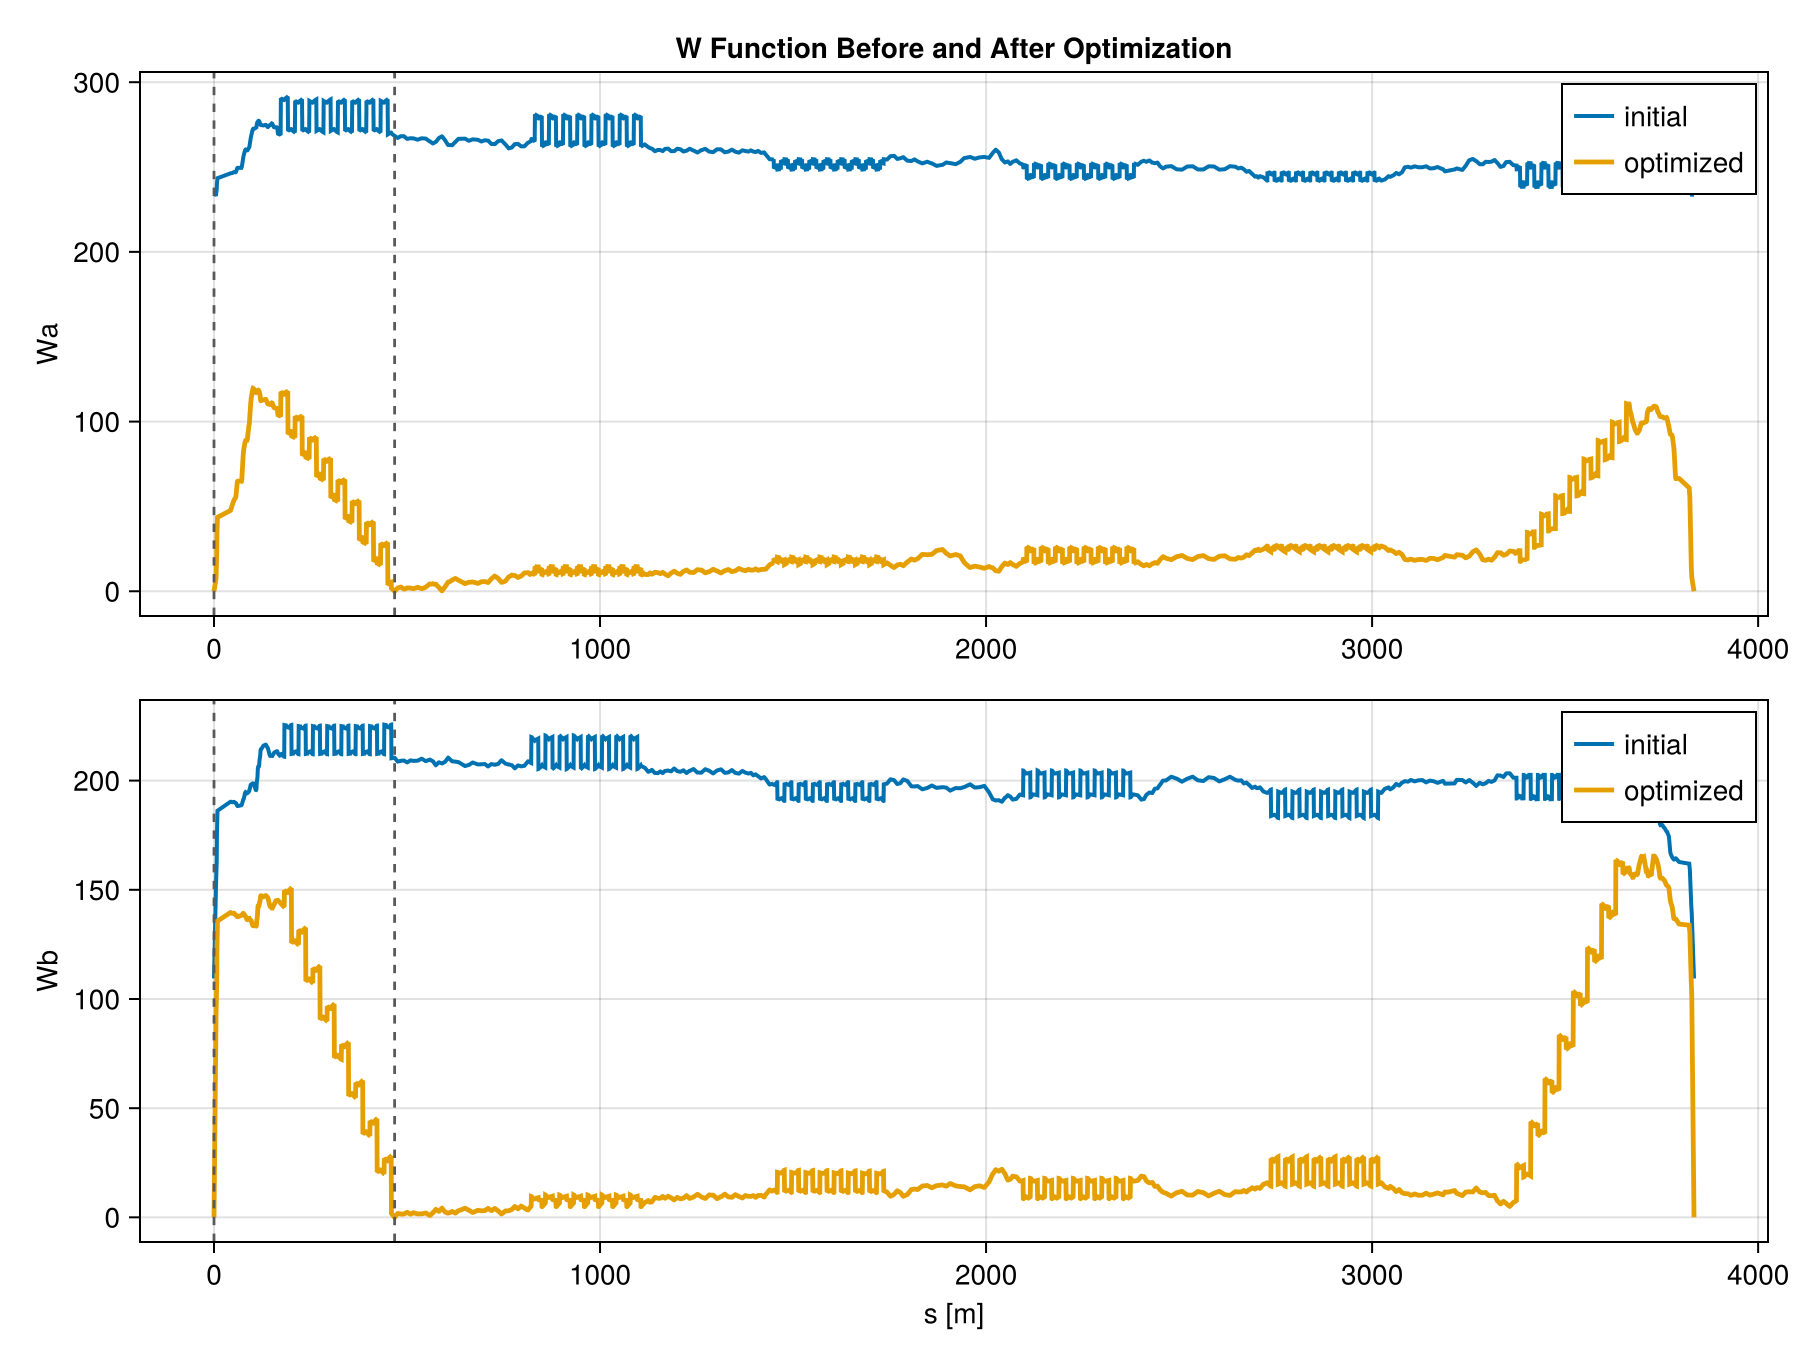

In [20]:
using CairoMakie

function ch12_w_profile(x; ring=ring_12_4)
    ch12_apply_w_knobs!(x)
    tw = twiss(ring; GTPSA_descriptor=Descriptor(6, 2))

    s = Float64.(tw.table.s)
    wa = Float64[]
    wb = Float64[]

    for idx in eachindex(s)
        a1, b1 = ch12_w_ab_plain(tw.table.beta_1[idx], tw.table.alpha_1[idx])
        a2, b2 = ch12_w_ab_plain(tw.table.beta_2[idx], tw.table.alpha_2[idx])
        push!(wa, hypot(ch12_scalar_constant(a1), ch12_scalar_constant(b1)))
        push!(wb, hypot(ch12_scalar_constant(a2), ch12_scalar_constant(b2)))
    end

    ch12_reset_w_controls!()
    return (; s, wa, wb)
end

initial_w_profile = ch12_w_profile(zeros(8))
optimized_w_profile = ch12_w_profile(optimized_ch12_w_knobs)
target_s = Float64[initial_w_profile.s[idx] for idx in ch12_w_target_indices]

w_figure = Figure(size=(900, 680))
axis_wa = Axis(
    w_figure[1, 1];
    ylabel="Wa",
    title="W Function Before and After Optimization",
)
axis_wb = Axis(
    w_figure[2, 1];
    xlabel="s [m]",
    ylabel="Wb",
)

lines!(axis_wa, initial_w_profile.s, initial_w_profile.wa; label="initial", linewidth=2.0)
lines!(axis_wa, optimized_w_profile.s, optimized_w_profile.wa; label="optimized", linewidth=2.4)
vlines!(axis_wa, target_s; color=:gray35, linestyle=:dash, linewidth=1.4)
axislegend(axis_wa; position=:rt)

lines!(axis_wb, initial_w_profile.s, initial_w_profile.wb; label="initial", linewidth=2.0)
lines!(axis_wb, optimized_w_profile.s, optimized_w_profile.wb; label="optimized", linewidth=2.4)
vlines!(axis_wb, target_s; color=:gray35, linestyle=:dash, linewidth=1.4)
axislegend(axis_wb; position=:rt)

linkxaxes!(axis_wa, axis_wb)
mkpath("assets")
save("assets/chapter12_w_function_optimization.png", w_figure)
w_figure


## 12.5 Exercise: IP and 2 o'clock Phase Trombones

Ideally, a trombone map can change the phase advance while leaving the other optical functions unchanged. In a real lattice, however, we still need to realize the desired phase advance by changing quadrupole strengths. At the same time, this matching process should keep the IP Twiss functions unchanged. Therefore, this exercise asks us to reproduce the trombone function near the connections from arc 5 and arc 7 to `IP6`: apply the same phase-advance changes, while preserving the Twiss functions at the IP.

At the IP there are four Twiss constraints, `beta_x`, `alpha_x`, `beta_y`, and `alpha_y`, plus two phase-advance constraints, one in each transverse plane. This gives six constraints in total, so at least six knobs are required. For each side we choose seven quadrupole knobs: three matching-section quadrupoles that connect to the IR, plus four IR quadrupoles on the corresponding side of `IP6`.

The exercise asks to build the phase-trombone setup that supports the W-function optimization. The goal is to control the phase advance between the sextupoles and the IP while keeping the IP optics unchanged. We also need to keep the total tune unchanged by adding another ideal trombone, which is selected to be added in the 2 o'clock tune cell.

The matching is split into three pieces:

1. add a 2 o'clock tune trombone, which compensates the total tune shift from the two IP-side trombones;
2. match the arc 5 side, from the arc-5 endpoint to `IP6`;
3. match the arc 7 side, from `IP6` to the arc-7 endpoint.

The solution code is kept as a separate notebook next to the chapter 12 lattice files:

```text
lattices/chapter_12/exercises/chapter12_phase_trombone_exercise.ipynb
```
